## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.constants import speed_of_light
from scipy.constants import epsilon_0
from scipy.constants import h

# Fundamental constants
mu_n = 0.762259323  # nuclear magneton in kHz / G (divide(d?) mu_N by h and convert to kHz / G)
g_i  = 5.5856946893 # proton g-factor
kb = 2.08366 * 10**7  # Boltzmann constant (divided by h to convert to kHz / K)

# Molecular constants
caoh_cij = 1.49  # nuclear spin-rotation coupling for J=2 for CaOH+ in kHz
caoh_gj = -0.036  # rotational g-factor for J=2 for CaOH+
caoh_br = 1.096 * 10**7  # rotational constant for CaOH+ in kHz
caoh_d = 6.3  # dipole moment of CaH+ in Debye (Michal Tomza)
vib_rate = 193.0  # vibrational SD decay rate in Hz (acc. to one number from Zhenlin)

caoh_nmr_params = {
    'c_ij': caoh_cij,
    'g_j': caoh_gj,
    'br': caoh_br,
    'd': caoh_d
}

A = 345.66837237412136  # Einstein A coefficient (from Zhenlins simulations) in s**-1

t_wait = 10             # time between the pulses in us
T_room = 300

rng = np.random.default_rng()

#### Get P-/R-branch transition probabilities from previous simulation

In [15]:
with open("../Off-Res_Excitation/fin_ex_list01_Jmax70_sigma8.5_original.pkl", "rb") as f:
    fin_ex_list10 = pickle.load(f)

print(len(fin_ex_list10))
print(fin_ex_list10)

# first half is the P-branch probabilities
pbranch_list = fin_ex_list10[:len(fin_ex_list10)//2]
pbranch_list = pbranch_list[::-1]       # invert list to go from the transition 1 --> 0 to the transition Jmax --> Jmax-1
pbranch_list = [0] + pbranch_list       # add a 0 in front to account for the nonexistent transitions from J=0
print(len(pbranch_list))
print(pbranch_list)

# second half is the R-branch probabilities
rbranch_list = fin_ex_list10[len(fin_ex_list10)//2 + 1:]
rbranch_list = rbranch_list + [0]       # add a 0 in the end to account for the (in this assumption) nonexistent transitions from Jmax upwards
print(len(rbranch_list))
print(rbranch_list)

# stack them together
# row 0: J -> J-1
# row 1: J -> J+1
p_exc = np.array([pbranch_list, rbranch_list])

141
[0.011689985196067117, 0.011795659147266728, 0.011885303494694625, 0.012054326837641504, 0.012170415302291309, 0.012240612035711586, 0.012409306187239658, 0.012526868683561435, 0.012594526270160942, 0.012758098971833129, 0.012885272438646402, 0.012942168397771072, 0.013100022113557343, 0.013232089405279415, 0.013281146039897856, 0.013425379330194102, 0.013570410398330705, 0.013611050158703428, 0.013744209816600166, 0.013897619140078279, 0.01393170067844299, 0.014055855706828125, 0.01421210340906318, 0.014243457765146347, 0.014343056321596916, 0.014514067383039014, 0.014539754213145392, 0.014623168663088333, 0.014801004294085367, 0.01482553046419025, 0.014882854615121071, 0.015067402641800412, 0.015096119124639517, 0.01512944776227742, 0.015317214659243295, 0.015354848432397376, 0.015358974974827033, 0.015548036168968325, 0.015613603713459103, 0.01557735343236017, 0.015767712340948245, 0.015820159274139073, 0.015765109092263398, 0.0159421903519423, 0.01602372494886175, 0.01593910176

#### Get spontaneous decay probability from Einstein A coefficient 

$$
P_{decay}=1-e^{-At}
$$

In [16]:
p_decay_total = 1 - np.exp(-A * t_wait / 1e6)       # decay probability, the same for all J
print("P_decay =", p_decay_total)

P_decay = 0.003450716270404719


#### Get the J_max, depending on the available transition probability data

In [17]:
J_max = len(p_exc[1]) - 1
print("J_max =", J_max)

J_max = 70


### Get BBR decay probabilities

In [18]:
def rate_decay_spont(J):
    '''Spontaneous decay rate: MQEC paper Eq. A3. This is here expressed in output units of 1/s; input units [B_R] = kHz, [d] = Debye.'''
    rate = 16 * (2 * np.pi)**3 * 10**(-33) * caoh_nmr_params['d']**2 * caoh_nmr_params['br']**3 * J**3 / (3 * epsilon_0 * h * speed_of_light**5)
    return rate
    
def rate_decay_bbr(sdr,Br,J,T):
    '''BBR stimulated emission rate: MQEC paper Eq. A9. This is here expressed in output units of 1/s; input units [B_R] = kHz, [T] = K.'''
    rate = sdr / (np.exp(2 * Br * J / (kb * T)) - 1)
    return rate

def rate_decay_bbr_down(J,T):
    return rate_decay_bbr(rate_decay_spont(J), caoh_nmr_params['br'], J, T)

def rate_decay_bbr_up(J,T):
    return rate_decay_bbr(rate_decay_spont(J+1), caoh_nmr_params['br'], J+1, T)

def rate_decay_down_total(J, T):
    return (1/(2*J + 1))*(J*(rate_decay_spont(J) + rate_decay_bbr_down(J, T)))

def rate_decay_up_total(J, T):
    return (1/(2*J + 1))*(J + 1) * rate_decay_bbr_up(J, T)

def make_rate_array(J_max, T):
    J_vals = np.arange(J_max + 1)

    rates_up = np.array([rate_decay_up_total(J, T) for J in J_vals])
    rates_down = np.array([rate_decay_down_total(J, T) for J in J_vals])

    rates = np.vstack((rates_up, rates_down))

    rates[0, -1] = 0   # last element of first row (up rates) (no decay to J levels higher than Jmax)
    rates[1, 0]  = 0   # first element of second row (down rates) (no decay downwards form J=0)

    return rates

def make_probability_array(rate_array, t):
    rates_up = rate_array[0]
    rates_down = rate_array[1]

    rates_total = rates_up + rates_down

    P_any = 1 - np.exp(-rates_total * t_wait * 1e-6)

    # avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        P_up = np.where(rates_total > 0,
                        rates_up / rates_total * P_any,
                        0)

        P_down = np.where(rates_total > 0,
                          rates_down / rates_total * P_any,
                          0)

    return np.vstack((P_up, P_down))

rate_array_bbr = make_rate_array(J_max, T_room)
P_bbr_array = make_probability_array(rate_array_bbr, t_wait)
print(P_bbr_array)

[[1.38512414e-08 3.68718811e-08 7.45345679e-08 1.25974568e-07
  1.91031489e-07 2.69609124e-07 3.61626210e-07 4.67006575e-07
  5.85676245e-07 7.17562378e-07 8.62592802e-07 1.02069580e-06
  1.19180000e-06 1.37583429e-06 1.57272782e-06 1.78240995e-06
  2.00481023e-06 2.23985842e-06 2.48748445e-06 2.74761846e-06
  3.02019073e-06 3.30513176e-06 3.60237219e-06 3.91184285e-06
  4.23347474e-06 4.56719903e-06 4.91294708e-06 5.27065038e-06
  5.64024064e-06 6.02164971e-06 6.41480962e-06 6.81965256e-06
  7.23611090e-06 7.66411719e-06 8.10360413e-06 8.55450459e-06
  9.01675163e-06 9.49027845e-06 9.97501846e-06 1.04709052e-05
  1.09778724e-05 1.14958539e-05 1.20247839e-05 1.25645965e-05
  1.31152261e-05 1.36766074e-05 1.42486750e-05 1.48313639e-05
  1.54246091e-05 1.60283459e-05 1.66425097e-05 1.72670361e-05
  1.79018608e-05 1.85469198e-05 1.92021491e-05 1.98674850e-05
  2.05428640e-05 2.12282225e-05 2.19234975e-05 2.26286257e-05
  2.33435443e-05 2.40681907e-05 2.48025021e-05 2.55464162e-05
  2.6299

C:\Users\miria\AppData\Local\Temp\ipykernel_27724\2718344631.py:8: RuntimeWarning: invalid value encountered in scalar divide
  rate = sdr / (np.exp(2 * Br * J / (kb * T)) - 1)


#### Set the initial state
Thermal state, so that J_max fits the maximum available data from the transition probability data.

In [19]:
def get_initial_state(T, Jmax):
    J = np.arange(0, Jmax + 1)
    exponents = - caoh_nmr_params['br'] * J * (J + 1) / (kb * T)
    boltzmann_factors = 2 * (2 * J + 1) * np.exp(exponents)
    Z = np.sum(boltzmann_factors)
    P_J = boltzmann_factors / Z
    return(P_J)

p_init = get_initial_state(T_room, J_max)
print(p_init)


[1.75255413e-03 5.23925791e-03 8.67106995e-03 1.20124604e-02
 1.52294691e-02 1.82902796e-02 2.11657420e-02 2.38298316e-02
 2.62600341e-02 2.84376494e-02 3.03480088e-02 3.19806021e-02
 3.33291151e-02 3.43913793e-02 3.51692384e-02 3.56683384e-02
 3.58978487e-02 3.58701264e-02 3.56003320e-02 3.51060102e-02
 3.44066467e-02 3.35232141e-02 3.24777172e-02 3.12927483e-02
 2.99910643e-02 2.85951911e-02 2.71270650e-02 2.56077145e-02
 2.40569884e-02 2.24933308e-02 2.09336052e-02 1.93929671e-02
 1.78847826e-02 1.64205912e-02 1.50101087e-02 1.36612657e-02
 1.23802773e-02 1.11717390e-02 1.00387428e-02 8.98300949e-03
 8.00503129e-03 7.10422055e-03 6.27906066e-03 5.52725494e-03
 4.84587071e-03 4.23147581e-03 3.68026552e-03 3.18817848e-03
 2.75100039e-03 2.36445520e-03 2.02428347e-03 1.72630815e-03
 1.46648835e-03 1.24096176e-03 1.04607663e-03 8.78414403e-04
 7.34803911e-04 6.12328514e-04 5.08327042e-04 4.20389736e-04
 3.46350153e-04 2.84273959e-04 2.32445430e-04 1.89352409e-04
 1.53670329e-04 1.242458

## Define necessary functions
#### Monte Carlo for initial state

In [20]:
def sample_initial_state(p_init):
    J = rng.choice(len(p_init), p=p_init)
    v = 0
    return v, J

#### One step of the process (one pulse)

In [21]:
def step_pulse(v, J, p_exc, J_max):
    if v == 0:                  # check that I am in the ground state at all
        # --- Excitation step ---
        p_down = p_exc[0, J]  # P-branch excitation: J -> J-1
        p_up   = p_exc[1, J]  # R-branch excitation: J -> J+1
        p_stay = 1.0 - (p_down + p_up)  # no excitation at all

        probs = [p_stay, p_down, p_up]
        choice = rng.choice(3, p=probs)

        if choice == 0:
            return 0, J  # stay in ground
        elif choice == 1 and J > 0:
            return 1, J - 1
        elif choice == 2 and J < J_max:
            return 1, J + 1
        else:
            return "Error" 
    
    elif v == 1:
        p_up = p_exc[0][1:]
        p_up = np.append(p_up, 0)
        p_up = p_up[J]
        p_down = p_exc[1][:-1]
        p_down = np.append(0, p_down)
        p_down = p_down[J]
        p_stay = 1.0 - (p_down + p_up)

        probs = [p_stay, p_down, p_up]
        choice = rng.choice(3, p=probs)

        if choice == 0:
            return v, J
        elif choice == 1 and J > 0:
            return 0, J - 1
        elif choice == 2 and J < J_max:
            return 0, J + 1
        else:
            return "Error"

def step_waittime(v, J, p_decay_total, J_max):
    if v == 1:

        # --- Decay step --
        if J != 0:
            prob_decay = p_decay_total
            prob_BBR_up = P_bbr_array[0][J]
            prob_BBR_down = P_bbr_array[1][J]
            prob_stay = 1 - prob_BBR_up - prob_BBR_down - prob_decay
            probs = [prob_stay, prob_decay, prob_BBR_up, prob_BBR_down]
            choice = rng.choice(4, p=probs)
            if choice == 0:
                return v, J
            elif choice == 1:
                if rng.random() < 0.5:
                    return 0, J - 1
                else:
                    return 0, J + 1
            elif choice == 2:
                return v, J + 1
            elif choice == 3:
                return v, J - 1
            else:
                return "Error"
        
        else:
            prob_decay = p_decay_total
            prob_BBR_up = P_bbr_array[0][J]
            prob_stay = 1 - prob_BBR_up - prob_decay
            probs = [prob_stay, prob_decay, prob_BBR_up]
            choice = rng.choice(3, p=probs)
            if choice == 0:
                return v, J
            elif choice == 1:
                return 0, J + 1
            elif choice == 2:
                return v, J + 1
            else:
                return "Error"
        
        
    else:
        prob_up = P_bbr_array[0][J]
        prob_down = P_bbr_array[1][J]
        prob_stay = 1 - prob_up - prob_down
        probs = [prob_stay, prob_up, prob_down]
        choice = rng.choice(3, p=probs)
        if choice == 0:
            return v, J
        elif choice == 1:
            return v, J + 1
        elif choice == 2:
            return v, J - 1
        else:
            return "Error"
    
def step_nolight(v, J, time_nolight):
    """time_nolight in us"""
    p_decay_nolight = 1 - np.exp(-A * time_nolight / 1e6)
    
    if v == 1:

        # --- Decay step --
        if J != 0:
            decay_randomnumber = rng.random()
            if decay_randomnumber < p_decay_nolight:

                # decay happens → split equally up/down
                direction_randomnumber = rng.random()
                if direction_randomnumber < 0.5:
                    return 0, J - 1
                else:
                    return 0, J + 1
            else:
                return 1, J  # remain excited
        
        else:
            decay_randomnumber = rng.random()
            if decay_randomnumber < p_decay_nolight:
                return 0, J + 1
        
            else:
                return v, J  # remain excited
        
        
    else:
        return v, J

#### Function to run one trajectory of the simulation

In [22]:
def run_simulation(n_cycles, p_init, p_exc, p_decay_total, J_max):
    v, J = sample_initial_state(p_init)    # initial state

    counter = 0
    trajectory = [(v, J)]

    for _ in range(n_cycles):
        # 1. pulse
        v, J = step_pulse(v, J, p_exc, J_max)

        # 2. wait time (decay)
        v, J = step_waittime(v, J, p_decay_total, J_max)

        # 3. add new state to trajectory
        trajectory.append((v, J))
        
        # 4. count cycle (always!)
        counter += 1

    return np.array(trajectory), counter

def run_simulation_with_nolight(n_cycles, p_init, p_exc, p_decay_total, J_max, time_nolight):
    v, J = sample_initial_state(p_init)    # initial state

    counter = 0
    trajectory = [(v, J)]

    for _ in range(n_cycles):
        # 1. pulse
        v, J = step_pulse(v, J, p_exc, J_max)

        # 2. wait time (decay)
        v, J = step_waittime(v, J, p_decay_total, J_max)

        # 3. add new state to trajectory
        trajectory.append((v, J))
        
        # 4. count cycle (always!)
        counter += 1

    v_final, J_final = step_nolight(v, J, time_nolight)
    
    return np.array(trajectory), counter, v_final, J_final

## Run one single trajectory

C:\Users\miria\AppData\Local\Temp\ipykernel_27724\1397534181.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(['', '0', '', '', '', '1'])


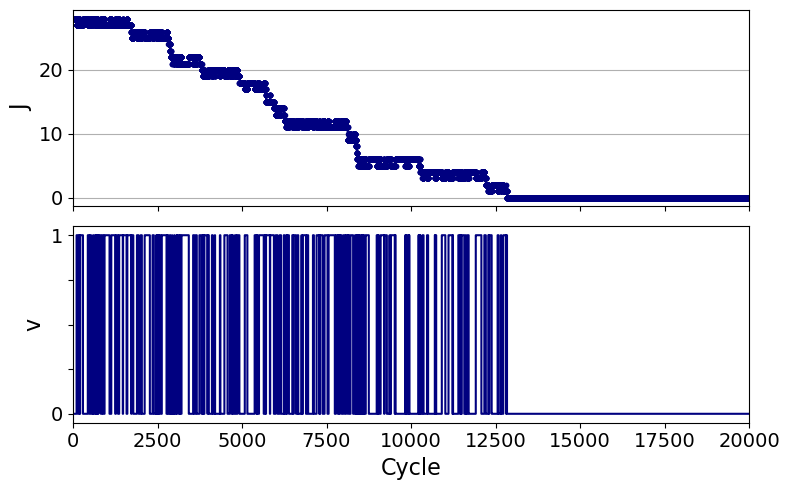

In [33]:
traj, counter = run_simulation(
    n_cycles=20000,
    p_init=p_init,
    p_exc=p_exc,
    p_decay_total=p_decay_total,
    J_max=J_max
)

v_vals = traj[:, 0]
J_vals = traj[:, 1]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

ax[0].plot(J_vals, marker='o', markersize=3, color='navy')
ax[0].set_ylabel("J", fontsize=16)
ax[0].grid(True, axis='y')
ax[0].set_xlim(0, 20000)
ax[0].tick_params(axis='both', labelsize=14)

ax[1].step(range(len(v_vals)), v_vals, where='post', color='navy')
ax[1].set_ylabel("v", fontsize=16)
ax[1].set_xlabel("Cycle", fontsize=16)
#ax[1].grid(True, axis='x')
ax[1].tick_params(axis='both', labelsize=14)
ax[1].set_yticklabels(['', '0', '', '', '', '1'])

plt.tight_layout()
plt.savefig("single_trajectory.pdf")
plt.show()

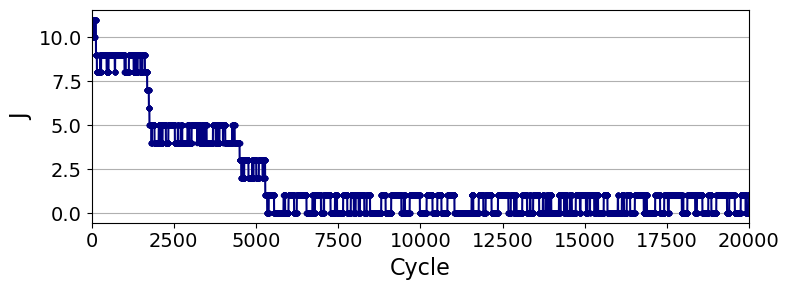

In [ ]:
# Alternative plotting
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(8, 3))

ax.plot(J_vals, marker='o', markersize=3, color='navy')
ax.set_ylabel("J", fontsize=16)
ax.grid(True, axis='y')
ax.set_xlim(0, 20000)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("Cycle", fontsize=16)
plt.tight_layout()
plt.savefig("single_trajectory_only.pdf")
plt.show()

## Run many trajectories

In [370]:
n_traj = 1000
n_cycles = 40000

J_all = np.zeros((n_traj, n_cycles + 1))
v_all = np.zeros((n_traj, n_cycles + 1))

for i in range(n_traj):
    traj, counter = run_simulation(
        n_cycles=n_cycles,
        p_init=p_init,
        p_exc=p_exc,
        p_decay_total=p_decay_total,
        J_max=J_max
    )
    
    v_all[i, :] = traj[:, 0]  # store v values
    J_all[i, :] = traj[:, 1]  # store J values

KeyboardInterrupt: 

In [ ]:
J_avg = np.mean(J_all, axis=0)
J_avg

array([20.248, 20.234, 20.22 , ...,  0.343,  0.345,  0.346])

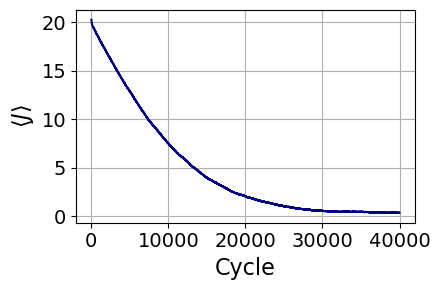

In [ ]:
plt.figure(figsize=(4.5, 3))
plt.plot(J_avg, color='navy')
plt.xlabel("Cycle", fontsize=16)
plt.ylabel(r'$\langle J \rangle$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig("average_J.pdf")
plt.show()

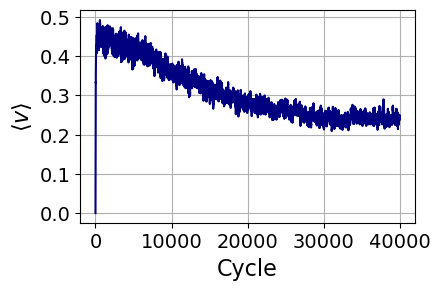

In [ ]:
v_avg = np.mean(v_all, axis=0)

plt.figure(figsize=(4.5, 3))
plt.plot(v_avg, color='navy')
plt.xlabel("Cycle", fontsize=16)
plt.ylabel(r'$\langle v \rangle$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig("average_v.pdf")
plt.show()

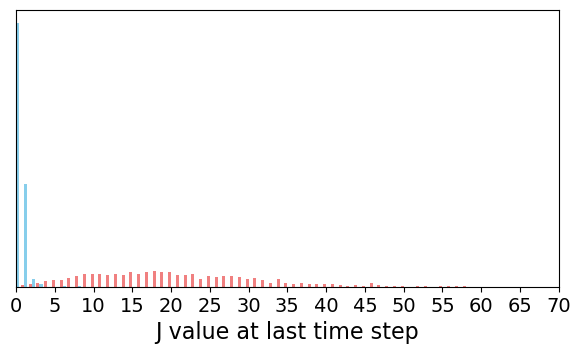

In [ ]:
# Extract the last time-step J values for all trajectories
J_last = J_all[:, -1].astype(int)
J_first = J_all[:, 0].astype(int)

# Count occurrences of each integer from 0 to 40
counts_last = np.bincount(J_last, minlength=J_max+1)  # minlength ensures 0–40 are all included
counts_first = np.bincount(J_first, minlength=J_max+1)

# Bar positions
x = np.arange(J_max + 1)  # 0 to 40
width = 0.4  # width of the bars

# Create bar plot
plt.figure(figsize=(7, 3.6))
plt.bar(x - width/2, counts_first, width=width, color='lightcoral', label='Before cooling')
plt.bar(x + width/2, counts_last, width=width, color='skyblue', label='After cooling')
plt.xlim([0, 35])

plt.xlabel('J value at last time step',  fontsize=16)
plt.xticks(range(0, J_max+1, 5),  fontsize=14)  # optional: show every 2 on x-axis for readability
plt.yticks([], fontsize=14)
plt.show()

## Run many trajectories with short waittime after cooling
(Almost) everything should fall back into the vibrational ground state

In [40]:
n_traj = 1000
n_cycles = 40000

J_all = np.zeros((n_traj, n_cycles + 1))
v_all = np.zeros((n_traj, n_cycles + 1))
v_final_list = []
J_final_list = []

for i in range(n_traj):
    traj, counter, v_final, J_final = run_simulation_with_nolight(
        n_cycles=n_cycles,
        p_init=p_init,
        p_exc=p_exc,
        p_decay_total=p_decay_total,
        J_max=J_max,
        time_nolight=200000 # in us, 1s
    )
    
    # Store full trajectories
    v_all[i, :] = traj[:, 0]  # store v values
    J_all[i, :] = traj[:, 1]  # store J values

    # Store final values (after waittime without light)
    v_final_list.append(v_final)
    J_final_list.append(J_final)

In [41]:
print(v_final_list)
print(J_final_list)
print(np.mean(J_final_list))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

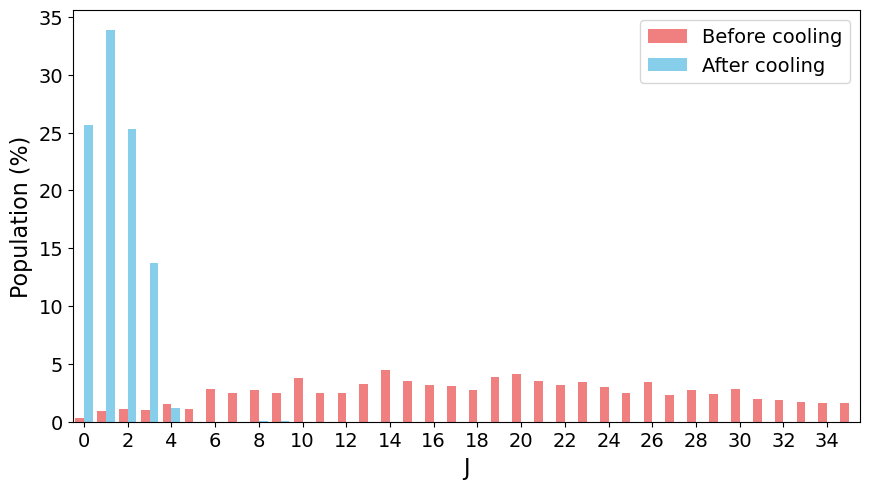

In [42]:
# Extract the last time-step J values for all trajectories
J_last = J_final_list
J_first = J_all[:, 0].astype(int)

# Total number of trajectories
ntrajectories = len(J_final_list)

# Count occurrences
counts_last = np.bincount(J_last, minlength=J_max+1) / ntrajectories * 100
counts_first = np.bincount(J_first, minlength=J_max+1) / ntrajectories * 100

# Bar positions
x = np.arange(J_max+1)
width = 0.4

# Plot
plt.figure(figsize=(8.8, 5))
plt.bar(x - width/2, counts_first, width=width, color='lightcoral', label='Before cooling')
plt.bar(x + width/2, counts_last, width=width, color='skyblue', label='After cooling')

plt.xlabel('J', fontsize=16)
plt.ylabel('Population (%)', fontsize=16)

plt.xticks(range(0, J_max+1, 2), fontsize=14)
plt.yticks(fontsize=14)

plt.xlim([-0.5, 35.5])

plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('distribution_after_cooling.pdf')
plt.show()

In [43]:
counts_last

array([25.7, 33.9, 25.3, 13.7,  1.2,  0. ,  0. ,  0. ,  0.1,  0.1,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ])